
* Roland Angelo Roccaro: rolandangelo.roccaro@students.bfh.ch

#### Reading instruction:
Do search for "Comment" which is always the heading used at where we comment on the seen/inspected results.

# 1 Overview
Reminder : the Mandatory Practical Works are intended to be done in groups of max 3 students.
The goal is to apply the concepts seen in the lectures and practical sessions, and to document
your experimentation process and results in a report. The report should be clear, concise, and
well-structured, and should include all relevant details about your experiments, including the
hyperparameters you used, the results you obtained, and any insights or conclusions you can
draw from your experiments.
Clearly state the group members at the beginning of the report :
* Student 1 : [Name, Surname]
* Student 2 : [Name, Surname]
* Student 3 : [Name, Surname]

In [6]:
import torch
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from  datetime import datetime
from torchsummary import summary
import os
import pandas as pd

%matplotlib inline

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

# Downloading dataset
The data set is downloaded from:
https://drive.switch.ch/index.php/s/NTiYe8mamrgys3M
* Size 345.5MB
* Extracted .zip is interestingly the same size


# 2 Objectives

## Mandatory objectives

* a)
Start from simple CNN architectures and progressively increase their complexity to show the benefit of depth.

* b)
Show the importance of hyperparameter tuning.

* c)
Show models that overfit and underfit and explain the reasons for that.

* d)
Experiment with regularization techniques.

* e)
Experiment with different optimization algorithms (e.g., Adam, RMSprop) and compare their performance.

---

## Hint

Resizing the images e.g., 128x128 or 64x64 may be useful at the beginning of your investigations to perform quicker experimentations and sweep towards good settings.


=== PATH CHECK ===
DATA_ROOT exists: True icosimal_img_class_03\data_uniform_224_224_sets
TRAIN_DIR exists: True icosimal_img_class_03\data_uniform_224_224_sets\train
VAL_DIR exists: True icosimal_img_class_03\data_uniform_224_224_sets\validate

=== DATASET CHECK ===
Number of training samples   : 24000
Number of validation samples : 6000

=== CLASS CHECK ===
Classes found: ['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']
Class to index mapping: {'cat': 0, 'chicken': 1, 'cow': 2, 'dog': 3, 'elephant': 4, 'horse': 5, 'rabbit': 6, 'sheep': 7, 'squirrel': 8, 'zebra': 9}
Number of classes: 10

=== SINGLE SAMPLE CHECK ===
Single image shape : torch.Size([3, 64, 64])
Single image dtype : torch.float32
Single label index : 0
Single label name  : cat
Pixel min / max    : 0.003921568859368563 1.0

=== BATCH CHECK ===
Batch image shape  : torch.Size([32, 3, 64, 64])
Batch label shape  : torch.Size([32])
Batch image dtype  : torch.float32
Batch label d

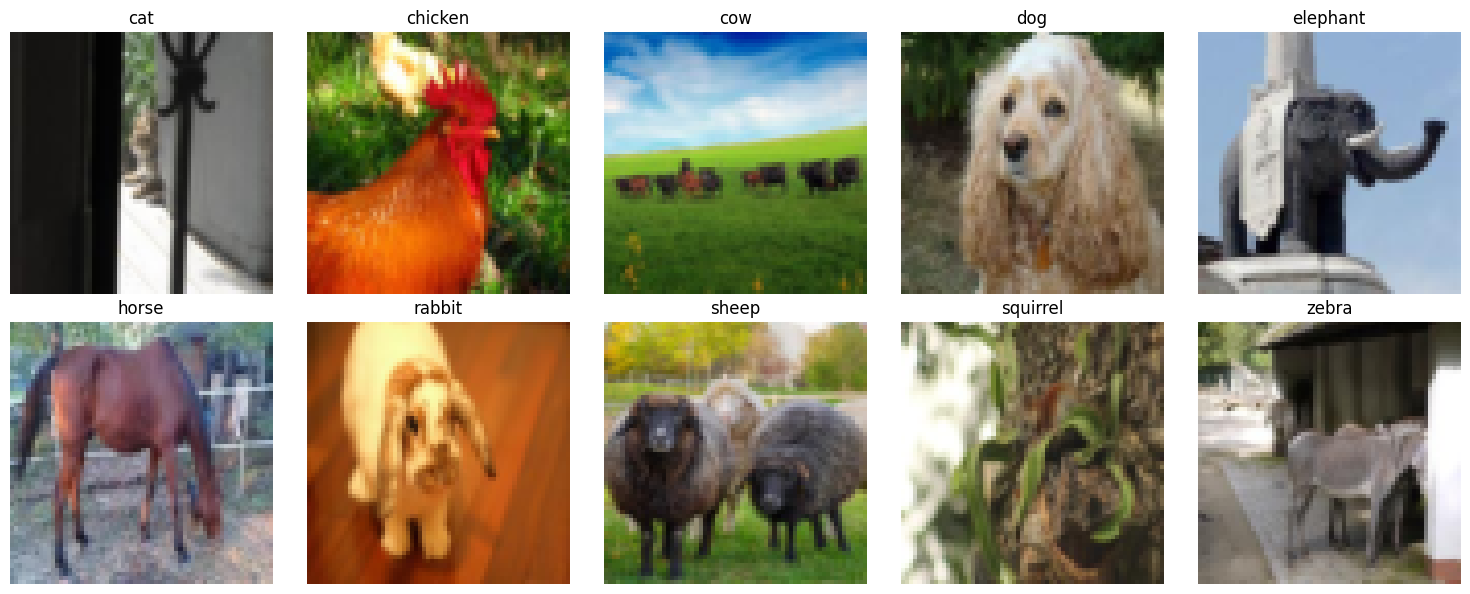

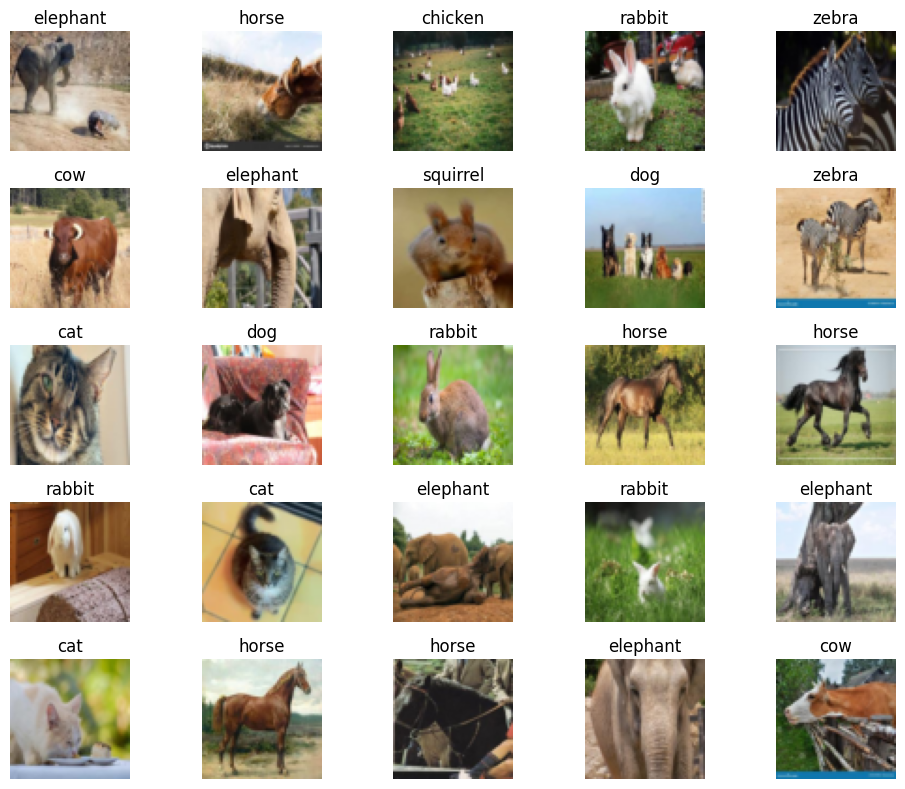

In [8]:
from pathlib import Path
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# =========================================================
# 1) Konfiguration
# =========================================================
DATA_ROOT = Path("icosimal_img_class_03/data_uniform_224_224_sets")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validate"

# Für erste CPU-Tests eher klein anfangen
IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0

device = torch.device("cpu")

# =========================================================
# 2) Vorprüfungen der Ordner
# =========================================================
print("=== PATH CHECK ===")
print("DATA_ROOT exists:", DATA_ROOT.exists(), DATA_ROOT)
print("TRAIN_DIR exists:", TRAIN_DIR.exists(), TRAIN_DIR)
print("VAL_DIR exists:", VAL_DIR.exists(), VAL_DIR)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT}")
if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")
if not VAL_DIR.exists():
    raise FileNotFoundError(f"VAL_DIR not found: {VAL_DIR}")

# =========================================================
# 3) Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),   # [0,255] -> float tensor in [0,1]
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

# =========================================================
# 4) Dataset laden
# =========================================================
train_data = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_data = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

# =========================================================
# 5) DataLoader
# =========================================================
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# =========================================================
# 6) Übliche Prüfungen / Sanity Checks
# =========================================================
print("\n=== DATASET CHECK ===")
print("Number of training samples   :", len(train_data))
print("Number of validation samples :", len(val_data))

print("\n=== CLASS CHECK ===")
print("Classes found:", train_data.classes)
print("Class to index mapping:", train_data.class_to_idx)
print("Number of classes:", len(train_data.classes))

# einzelnes Sample prüfen
img0, label0 = train_data[0]

print("\n=== SINGLE SAMPLE CHECK ===")
print("Single image shape :", img0.shape)       # erwartet [C, H, W]
print("Single image dtype :", img0.dtype)
print("Single label index :", label0)
print("Single label name  :", train_data.classes[label0])
print("Pixel min / max    :", img0.min().item(), img0.max().item())

# Batch prüfen
batch_imgs, batch_labels = next(iter(train_loader))

print("\n=== BATCH CHECK ===")
print("Batch image shape  :", batch_imgs.shape)   # erwartet [B, C, H, W]
print("Batch label shape  :", batch_labels.shape) # erwartet [B]
print("Batch image dtype  :", batch_imgs.dtype)
print("Batch label dtype  :", batch_labels.dtype)
print("Batch pixel min/max:", batch_imgs.min().item(), batch_imgs.max().item())

# zusätzliche Plausibilitätsprüfung
assert img0.ndim == 3, f"Expected single image ndim=3, got {img0.ndim}"
assert batch_imgs.ndim == 4, f"Expected batch image ndim=4, got {batch_imgs.ndim}"
assert batch_labels.ndim == 1, f"Expected batch label ndim=1, got {batch_labels.ndim}"
assert img0.shape[0] in [1, 3], f"Unexpected channel count: {img0.shape[0]}"
assert len(train_data.classes) > 1, "Less than 2 classes found"
assert 0.0 <= img0.min() and img0.max() <= 1.0, "Tensor values are not in [0,1]"

print("\nAll basic sanity checks passed.")

# =========================================================
# 7) Klassen ausgeben
# =========================================================
print("\n=== CLASS LIST ===")
for idx, class_name in enumerate(train_data.classes):
    print(f"{idx:2d}: {class_name}")

# =========================================================
# 8) Von jeder Klasse genau ein Bild anzeigen
# =========================================================
def show_one_image_per_class(dataset):
    """
    Zeigt für jede Klasse ein Beispielbild.
    """
    classes = dataset.classes
    found = {class_name: None for class_name in classes}

    # suche erstes Bild pro Klasse
    for i in range(len(dataset)):
        img, label = dataset[i]
        class_name = classes[label]
        if found[class_name] is None:
            found[class_name] = (img, label)

        # stoppe wenn alle Klassen gefunden wurden
        if all(found[c] is not None for c in classes):
            break

    n_classes = len(classes)
    cols = min(5, n_classes)
    rows = (n_classes + cols - 1) // cols

    plt.figure(figsize=(3 * cols, 3 * rows))

    for idx, class_name in enumerate(classes, start=1):
        img, label = found[class_name]
        plt.subplot(rows, cols, idx)
        plt.imshow(img.permute(1, 2, 0))
        plt.title(f"{class_name}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_one_image_per_class(train_data)

# =========================================================
# 9) Zufällige Bilder anzeigen (ähnlich deinem CIFAR-Beispiel)
# =========================================================
def show_imgs(X, n=25):
    figure = plt.figure(figsize=(10, 8))
    cols, rows = 5, 5

    for i in range(1, min(n, cols * rows) + 1):
        sample_idx = torch.randint(len(X), size=(1,)).item()
        img, label = X[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(X.classes[label])
        plt.axis("off")
        plt.imshow(img.permute(1, 2, 0))

    plt.tight_layout()
    plt.show()

show_imgs(train_data)